In [1]:
from sklearn.decomposition import PCA
from torch import nn
import torch
import torchvision

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from matplotlib.animation import FuncAnimation
from pathlib import Path
from tqdm import tqdm
import numpy as np
import joblib

from lib.viz.plotting import (
    plot_sagd_heatmap_row_with_prob,
    plot_breakpoint_and_speciation,
    plot_state_and_ctd_frame,
    extended_gray_coolwarm
    )
from lib.ou_model import find_third_phase_onset
from lib.diffusion_model.resnet_classifier import ResNet

import warnings
from scipy.integrate import IntegrationWarning
warnings.filterwarnings("ignore", category=IntegrationWarning)

In [2]:
ROOT = Path('/extra/shared/groups/marinaivan/data_marina')

## Bimodal Gaussian

In [3]:
ds = [2, 50, 256, 1024, 16384]
exp_path = ROOT/ Path('recurrence_matrices/bimodal_gaussian_SAGD_log_scale_and_shift_clipped')
n = 1000
W_list = []
time_snaps_vector_list, ts_tuple_list, tsagd_tuple_list = [], [], []
sagd_dms = []
ts_list, tsagd_list, t_star_list = [], [], []
ctds_list = []
std = 1.0

for d_i in ds:
    history = joblib.load(exp_path / f"D{d_i}_N{n}_T10/history.jbl")
    breakpoints = joblib.load(exp_path / f"D{d_i}_N{n}_T10/clusters.jbl")
    W_list.append(joblib.load(exp_path / f"D{d_i}_N{n}_T10/Ws.jbl"))
    ctds = joblib.load(exp_path / f"D{d_i}_N{n}_T10/CTDs.jbl")
    ctds_list.append(ctds)
    sagd_dms.append(joblib.load(exp_path / f"D{d_i}_N{n}_T10/SAGD.jbl"))
    mu = history['params']['mu']
    snaps = history['params']['times_snapshots']
    t_s_i = history['params']['ts_theoretical']
    t_sagd_idx = breakpoints[0]
    t_sagd = snaps[t_sagd_idx]
    ts_list.append(t_s_i)
    t_star_list.append(find_third_phase_onset(ctds['CTDs'], snaps))
    ts_tuple_list.append((t_s_i, int(np.argmin(np.abs(snaps - t_s_i)))))
    tsagd_list.append(t_sagd)
    tsagd_tuple_list.append((t_sagd, t_sagd_idx))
    time_snaps_vector_list.append(snaps)
    print({"Dim: {}, breakpoints: {}".format(d_i, breakpoints)})

{'Dim: 2, breakpoints: [np.int64(218), np.int64(219), np.int64(220), np.int64(222), np.int64(223), np.int64(224), np.int64(227), np.int64(228), np.int64(229)]'}
{'Dim: 50, breakpoints: [np.int64(180), np.int64(183), np.int64(185), np.int64(186), np.int64(187), np.int64(202), np.int64(214), np.int64(219), np.int64(229)]'}
{'Dim: 256, breakpoints: [np.int64(163), np.int64(165), np.int64(170), np.int64(171), np.int64(199), np.int64(200), np.int64(204), np.int64(217), np.int64(228)]'}
{'Dim: 1024, breakpoints: [np.int64(148), np.int64(152), np.int64(154), np.int64(197), np.int64(198), np.int64(199), np.int64(212), np.int64(220), np.int64(231)]'}
{'Dim: 16384, breakpoints: [np.int64(127), np.int64(207), np.int64(216), np.int64(229)]'}


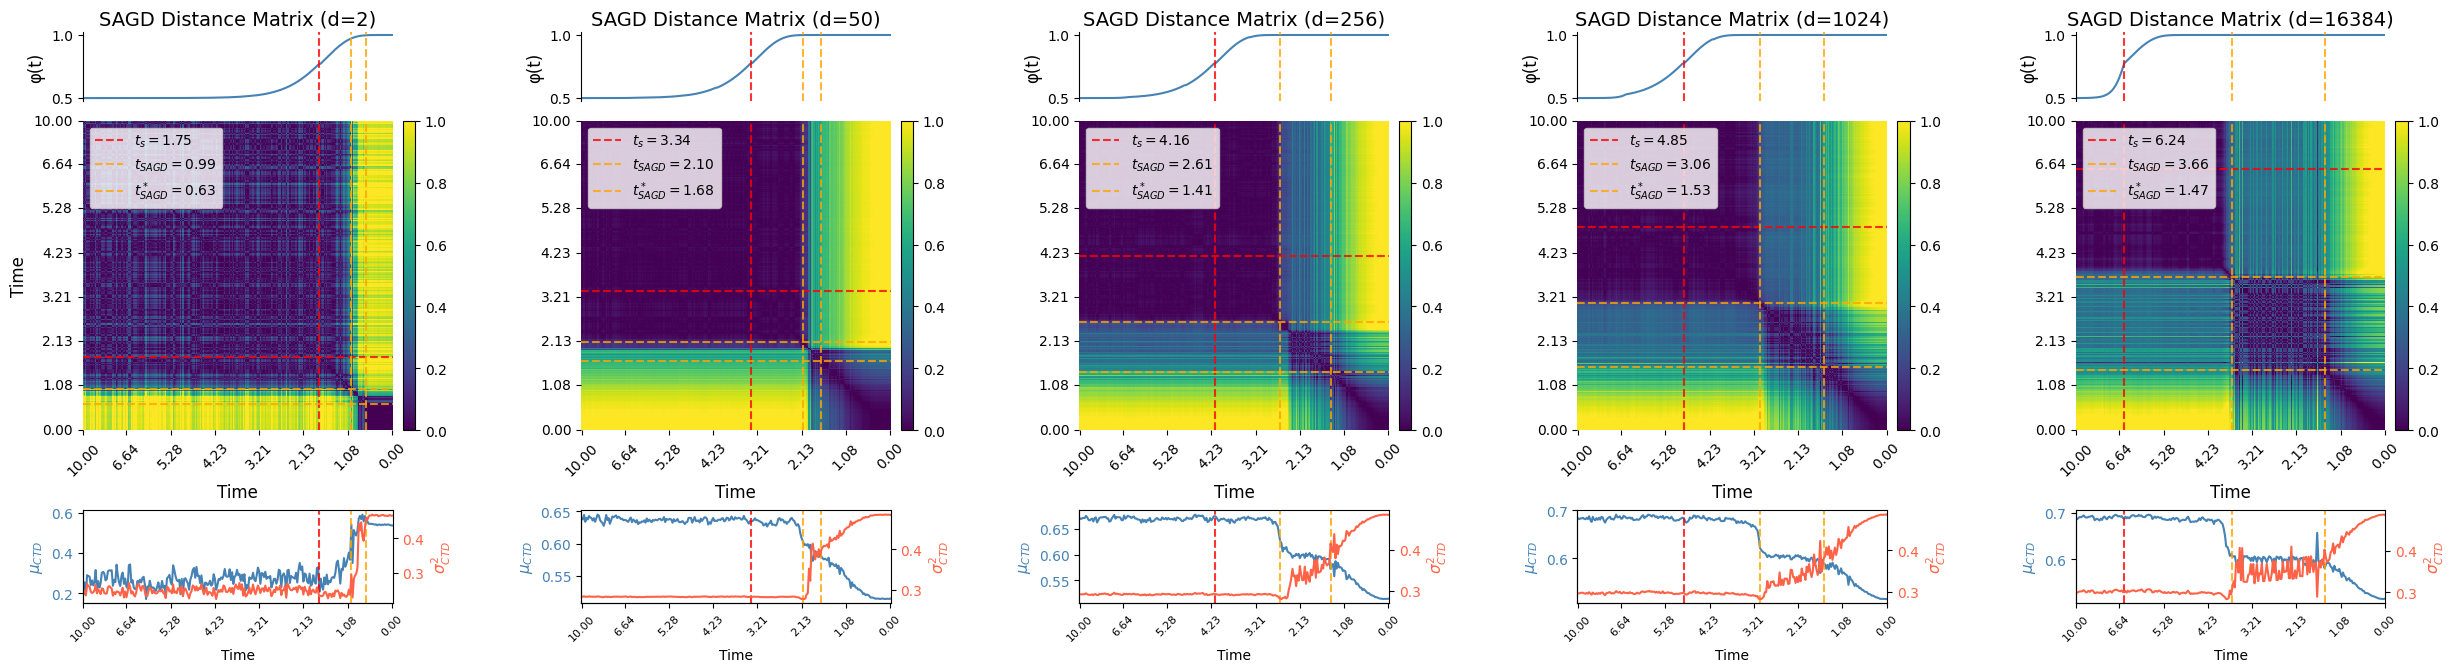

In [4]:
plot_sagd_heatmap_row_with_prob(
    W_list=sagd_dms,
    d_list=ds,
    time_snaps_vector_list=time_snaps_vector_list,
    mu=mu,
    std=std,
    ts_list=ts_list,
    tsagd_list=tsagd_list,
    tstar_list=t_star_list,
    ctds_list=ctds_list,
    distance='SAGD',
    model='synthetic',
    save_fig_path='figs/sagd_hetmap_row_with_prob_bimodal_gaussian.png',
    show_prob=True
)

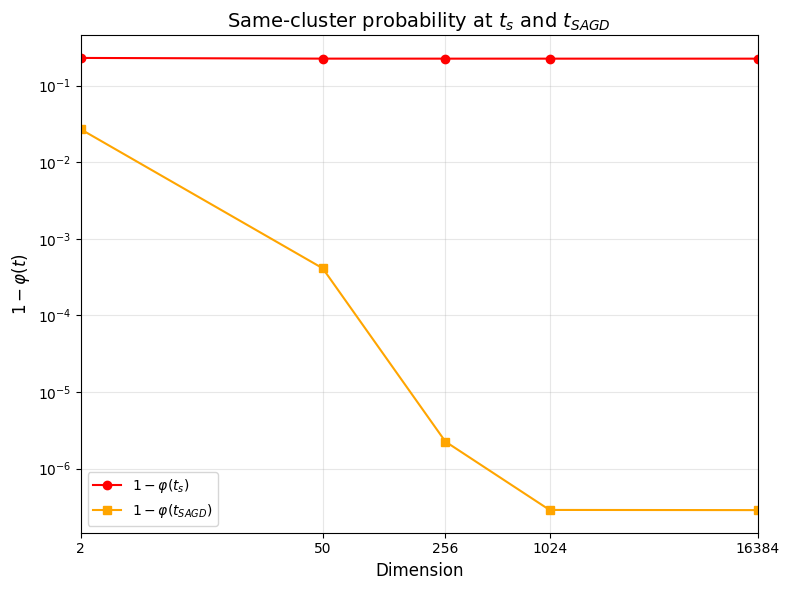

In [7]:
plot_breakpoint_and_speciation(
        d_list=ds,
        ts_tuple_list=ts_tuple_list,
        tsagd_tuple_list=tsagd_tuple_list,
        mu=mu,
        std=std,
        save_fig_path='figs/speciation_and_sagd_times.png',
)

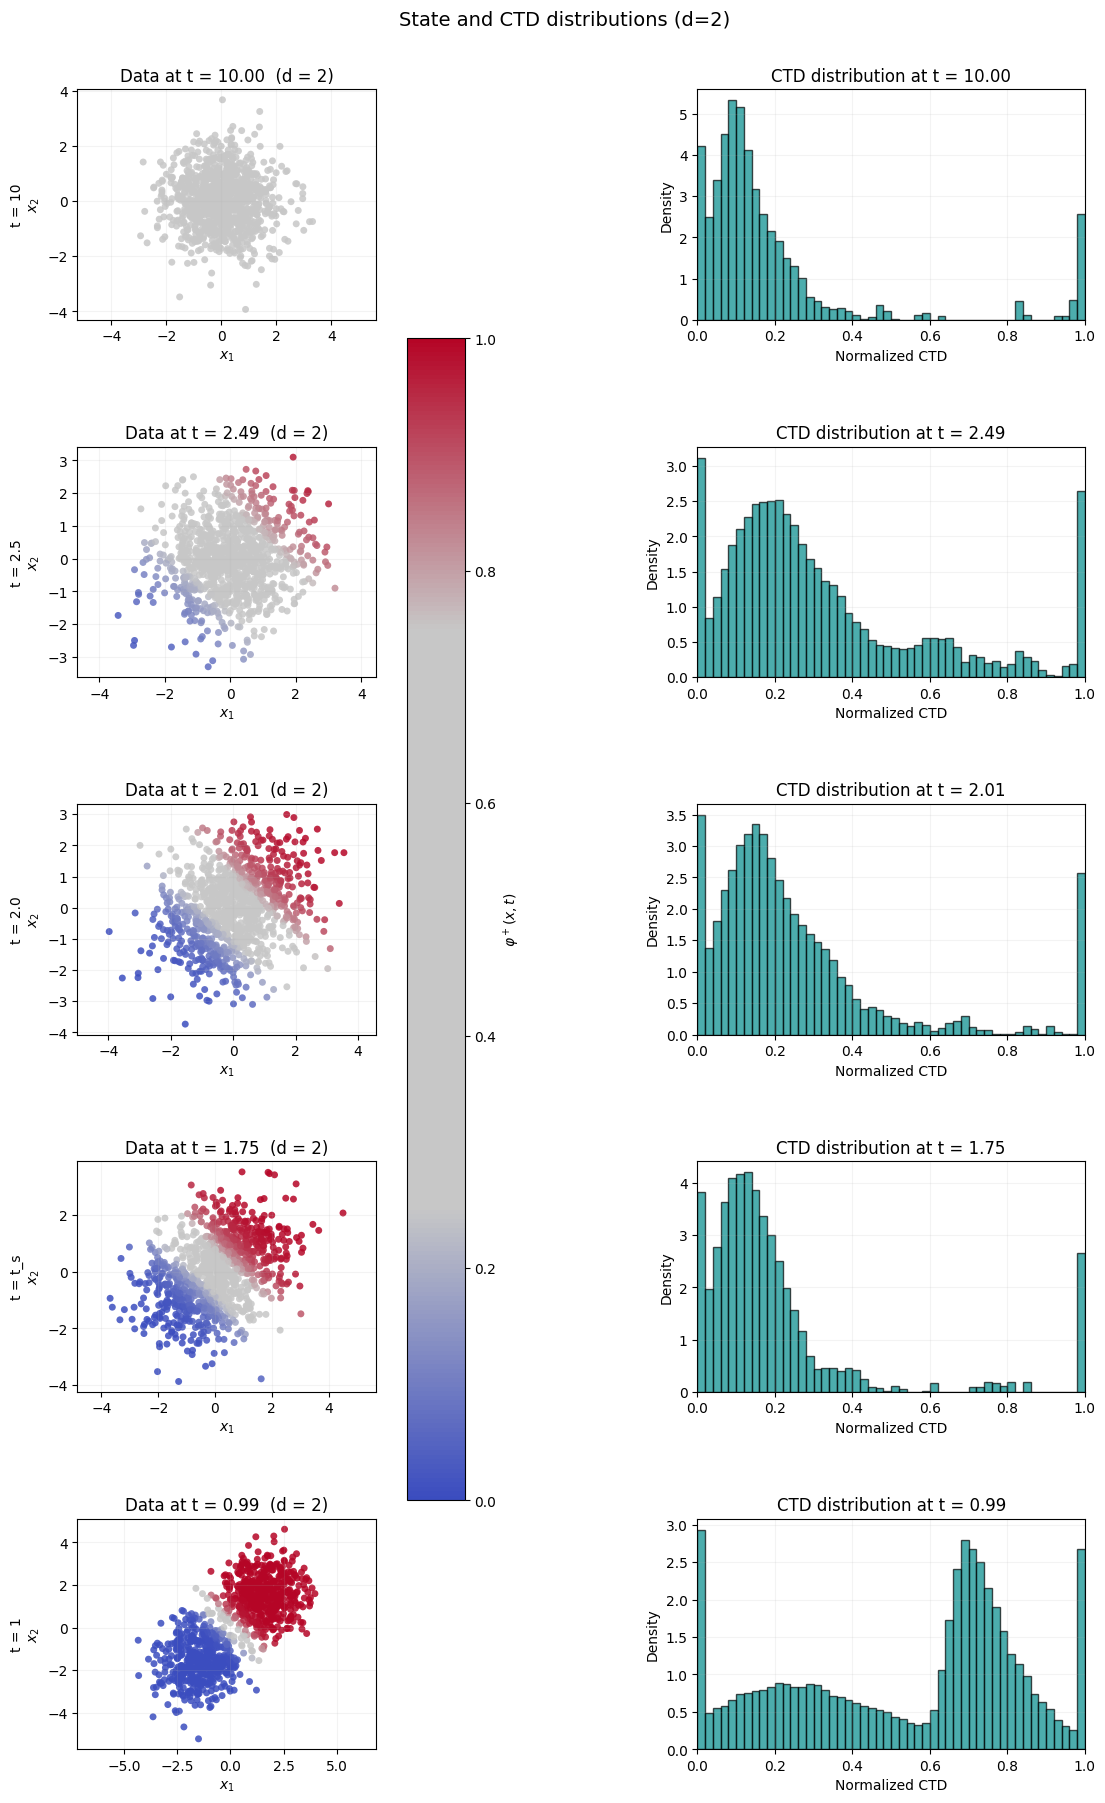

In [8]:
d_plot = 2
hist_load = joblib.load(exp_path / f"D{d_plot}_N1000_T10/history.jbl")
ctds_load = joblib.load(exp_path / f"D{d_plot}_N1000_T10/CTDs.jbl")

history = hist_load['history']
ctds_dict = ctds_load['CTDs']
t_s_d = hist_load['params']['ts_theoretical']
mu_d = hist_load['params']['mu']

time_snaps = list(history.keys())
ts_arr = np.array(time_snaps)
history_list = [history[t] for t in time_snaps]
norm_ctds_list = [ctds_dict[t]['norm_ctds'] for t in time_snaps]

target_times = [10.0, 2.5, 2.0, t_s_d, 1.0]
target_labels = ['t = 10', 't = 2.5', 't = 2.0', 't = t_s', 't = 1']
target_idx = [int(np.argmin(np.abs(ts_arr - tt))) for tt in target_times]

fig, axes = plt.subplots(len(target_idx), 2, figsize=(13, 4 * len(target_idx)))
fig.subplots_adjust(hspace=0.55, wspace=0.6, top=0.94)

for row, (idx, lbl) in enumerate(zip(target_idx, target_labels)):
    plot_state_and_ctd_frame(
        step_idx=idx,
        history_list=history_list,
        norm_ctds_list=norm_ctds_list,
        time_snaps=time_snaps,
        mu=mu_d,
        std=std,
        fig=fig,
        axes=axes[row],
        show=False,
    )
    axes[row, 0].set_ylabel(f"{lbl}\n{axes[row, 0].get_ylabel()}")

sm = ScalarMappable(cmap=extended_gray_coolwarm(), norm=Normalize(0.0, 1.0))
sm.set_array([])
fig.colorbar(sm, ax=axes[:, 0].ravel().tolist(), shrink=0.7, pad=0.08,
             label=r"$φ^+(x, t)$")
fig.suptitle(f"State and CTD distributions (d={d_plot})", fontsize=14)
plt.show()

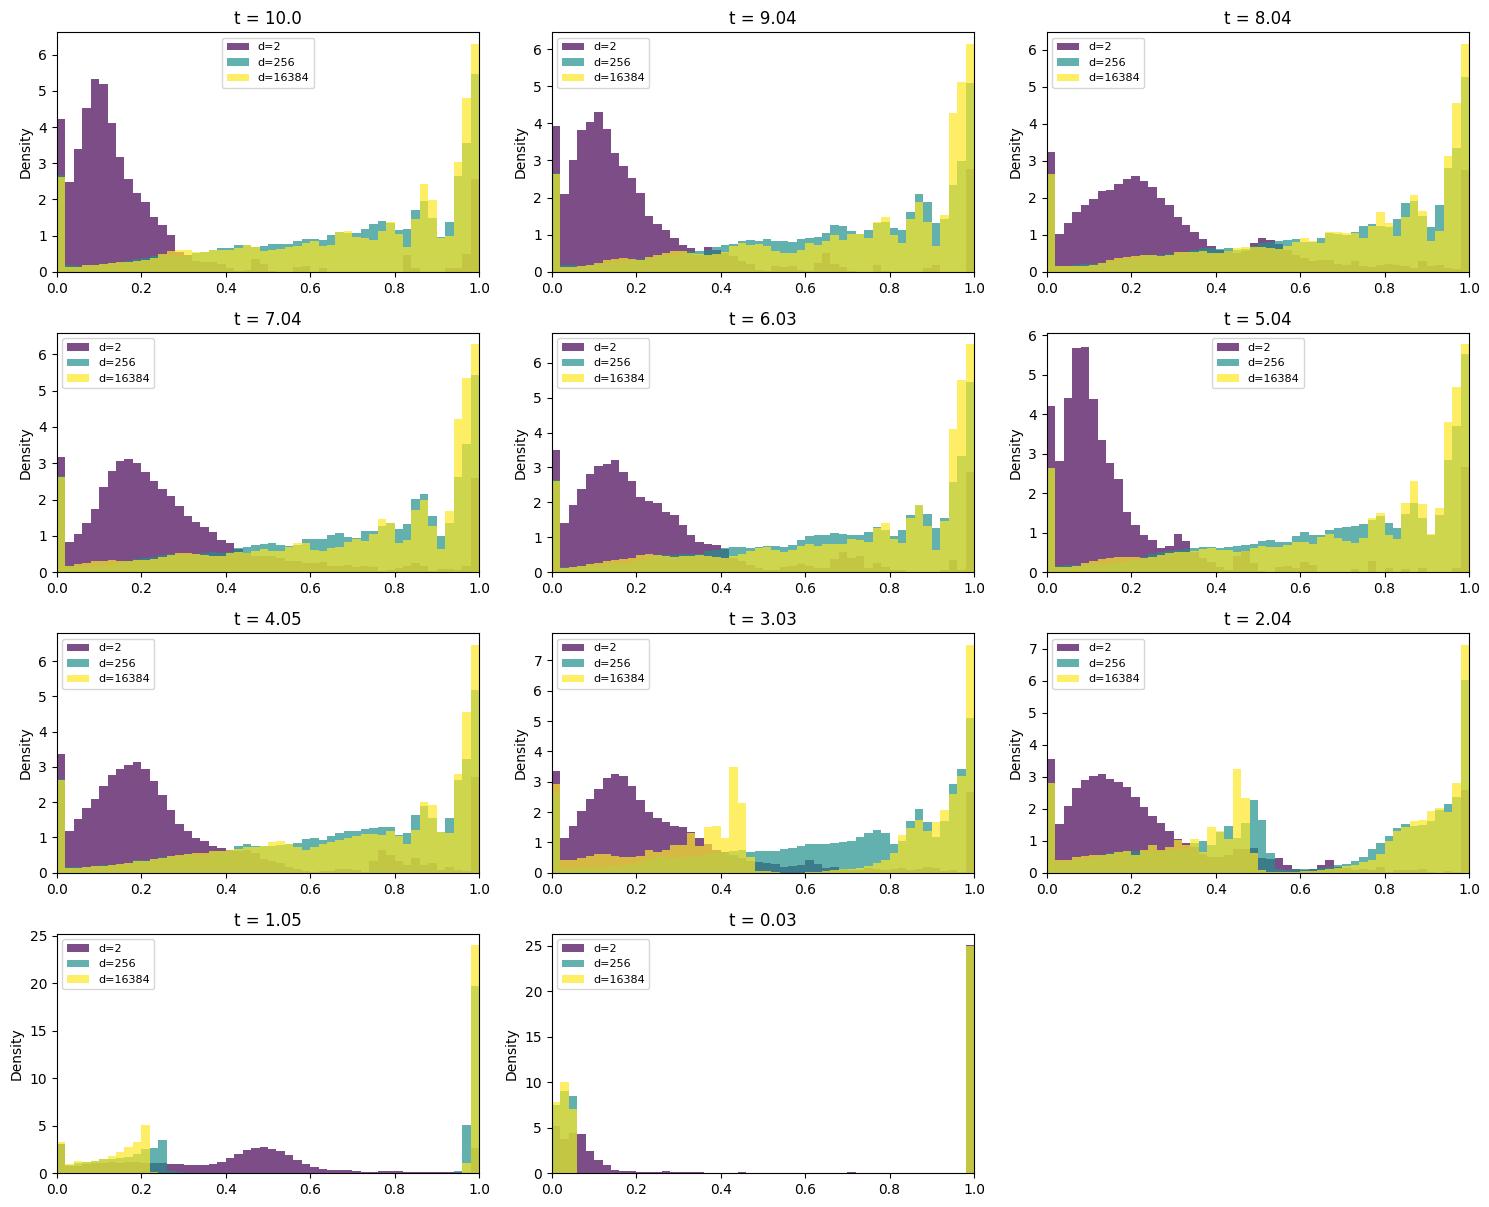

In [4]:
ds = [2, 256, 16384] 
colors = plt.cm.viridis(np.linspace(0, 1, len(ds)))

data = {}
for d in ds:
    data[d] = joblib.load(exp_path / f"D{d}_N1000_T10/CTDs.jbl")
    
shared_bins = np.linspace(0, 1, 51)
t_subset = sorted([t for t in snaps if 0.5 <= t <= 2.0])
n = len(t_subset)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3))
axes = axes.flatten()
ts = [[i for idx, i in enumerate(data[d]['CTDs'].keys()) if round(i, 1) == j][0] for j in [k for k in range(0, 11, 1)[::-1]]]
for i, t in enumerate(ts):
    for idx, d in enumerate(ds):
        axes[i].hist(data[d]['CTDs'][t]['norm_ctds'], bins=shared_bins, alpha=0.7, density=True, 
                    color=colors[idx], label=f'd={d}')
        
        axes[i].set_title(f't = {round(t, 3)}')
        axes[i].set_ylabel('Density')
        axes[i].set_xlim(0, 1)
        axes[i].legend(fontsize=8)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
# save_path = 'figs/exmp.png'
# if save_path:
#     plt.savefig(save_path)
plt.show()

## Hierarchical Gaussian

In [5]:
ds = [3, 50, 256, 1024, 16384]

exp_path = ROOT / Path('recurrence_matrices/hierarchical_gaussian_SAGD_log_scale_and_shift_clipped')
n = 2500
W_list = []
time_snaps_vector_list = []
sagd_dms = []
ts_list, tsagd_list, t_star_list = [], [], []
ctds_list = []

for d_i in ds:
    history = joblib.load(exp_path / f"D{d_i}_N{n}_T10/history.jbl")
    breakpoints = joblib.load(exp_path / f"D{d_i}_N{n}_T10/clusters.jbl")
    W_list.append(joblib.load(exp_path / f"D{d_i}_N{n}_T10/Ws.jbl"))
    ctds = joblib.load(exp_path / f"D{d_i}_N{n}_T10/CTDs.jbl")
    ctds_list.append(ctds)
    sagd_dms.append(joblib.load(exp_path / f"D{d_i}_N{n}_T10/SAGD.jbl"))
    mu = history['params']['mu']
    snaps = history['params']['times_snapshots']
    # ts_list.append(history['params']['ts_theoretical'])
    tsagd_list.append(snaps[breakpoints[0]])
    t_star_list.append(find_third_phase_onset(ctds['CTDs'], snaps))
    print({"Dim: {}, breakpoints: {}".format(d_i, breakpoints)})
    time_snaps_vector_list.append(snaps)
    
    

{'Dim: 3, breakpoints: [np.int64(86), np.int64(87), np.int64(88), np.int64(89), np.int64(90), np.int64(95), np.int64(96), np.int64(97), np.int64(99)]'}
{'Dim: 50, breakpoints: [np.int64(83), np.int64(87), np.int64(88), np.int64(89), np.int64(90), np.int64(92), np.int64(93), np.int64(95), np.int64(97)]'}
{'Dim: 256, breakpoints: [np.int64(97), np.int64(98), np.int64(99)]'}
{'Dim: 1024, breakpoints: [np.int64(99), np.int64(100)]'}
{'Dim: 16384, breakpoints: [np.int64(67), np.int64(74), np.int64(86), np.int64(87), np.int64(89), np.int64(90), np.int64(91), np.int64(96), np.int64(98)]'}


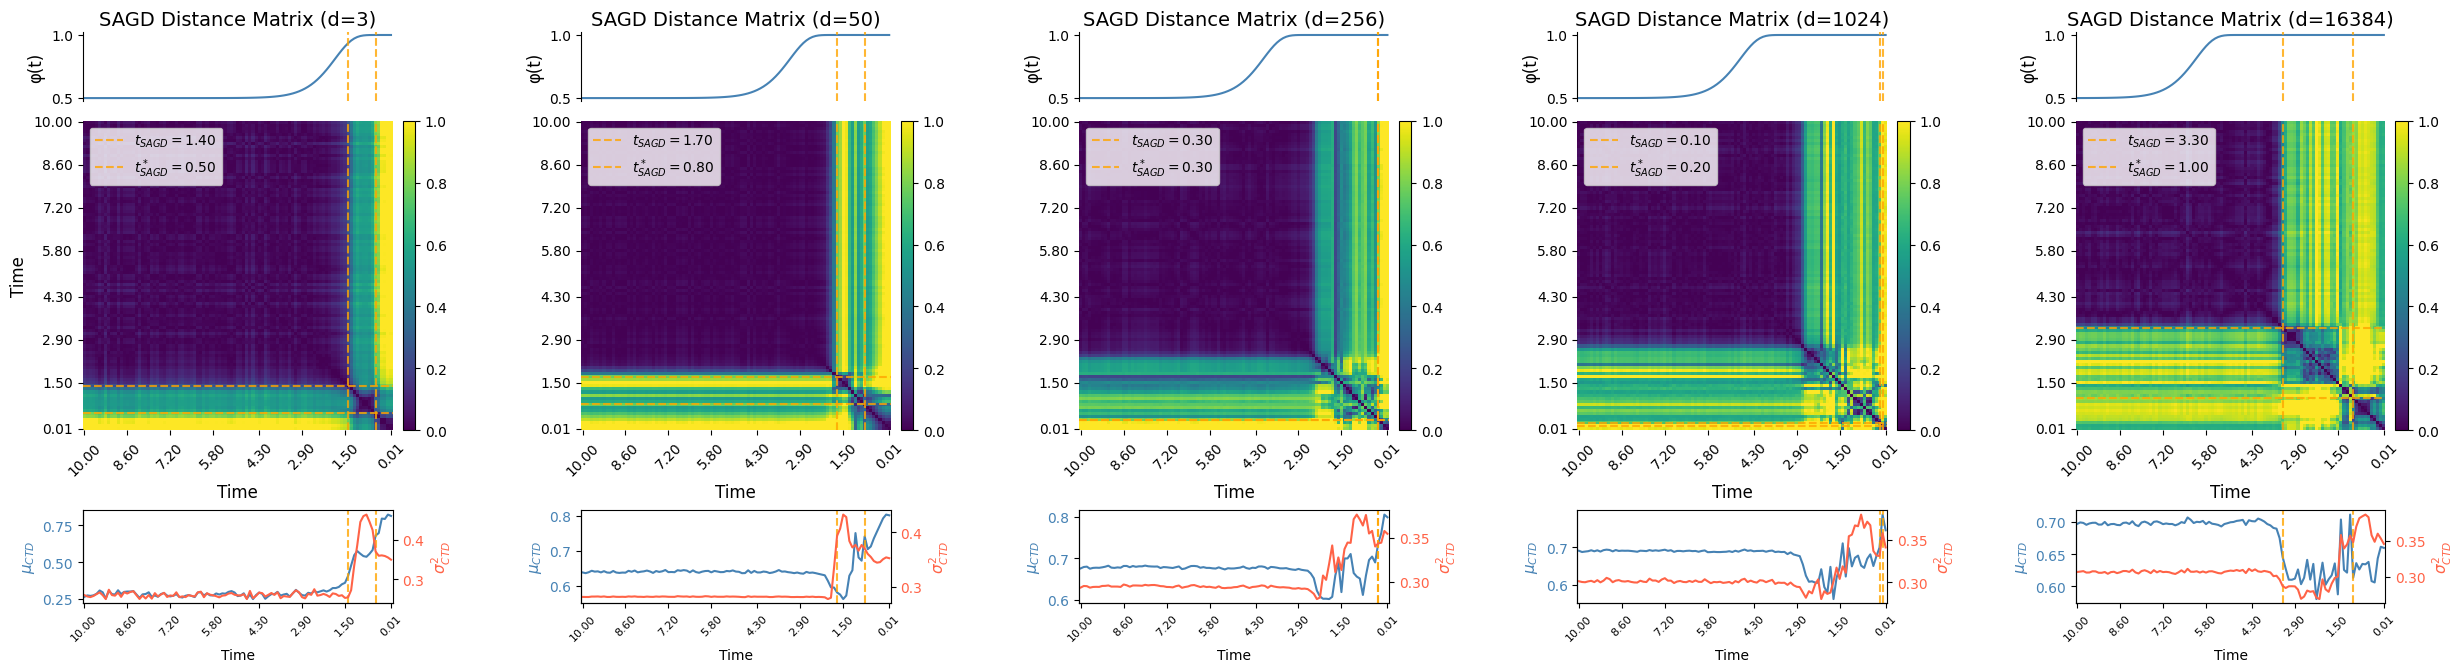

In [6]:
plot_sagd_heatmap_row_with_prob(
    W_list=sagd_dms,
    d_list=ds,
    time_snaps_vector_list=time_snaps_vector_list,
    mu=mu,
    std=std,
    ts_list=None,
    tsagd_list=tsagd_list,
    tstar_list=t_star_list,
    ctds_list=ctds_list,
    distance='SAGD',
    model='synthetic',
    save_fig_path='figs/sagd_hetmap_row_with_prob_hierarchical_gaussian.png',
    show_prob=True
)